# Week 3 Assignment – Customer Intelligence System

## Classification, Ensemble Learning & Clustering on Country Data

**Dataset:** [Unsupervised Learning on Country Data](https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data)  
**Reference:** [Kaggle Notebook](https://www.kaggle.com/code/jatin2bagga/unsupervised-learning-on-country-data/notebook)  

---

### Objective
Develop an end-to-end **Customer Intelligence System** using classification, ensemble learning (Random Forest, XGBoost), and clustering (K-Means, DBSCAN), achieving optimized predictive performance and actionable customer segmentation insights.

### Approach
1. Load, clean and explore the Country Data
2. Engineer a target variable (development category) for classification
3. Train **Random Forest** and **XGBoost** classifiers (ensemble learning)
4. Evaluate with Accuracy, Precision, Recall, F1, Confusion Matrix
5. Extract **Feature Importance**
6. Apply **K-Means** and **DBSCAN** clustering for unsupervised segmentation
7. Profile clusters and derive actionable insights

---
## 1. Install & Import Libraries

In [2]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

# Classification / Ensemble
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    silhouette_score, davies_bouldin_score
)

# Clustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

# Dendrogram (optional viz)
from scipy.cluster.hierarchy import dendrogram, linkage

PALETTE = ['#9b59b6', '#e91e8c', '#3498db', '#e74c3c', '#2ecc71']

sns.set(style='darkgrid')
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', 100)

print('All libraries imported successfully!')

All libraries imported successfully!


---
## 2. Load & Inspect the Dataset

In [4]:
df = pd.read_csv('C:/Users/khush/OneDrive/Desktop/Celebal/week3_assignment/3rd_week_dataset.csv')

print(f'Shape: {df.shape}')
df.head()

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [5]:
df.info()
print('\n')
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB




,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


In [6]:
print('Missing values:\n', df.isnull().sum())
print(f'\nDuplicates: {df.duplicated().sum()}')

Missing values:
 country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Duplicates: 0


---
## 3. Data Cleaning & Preprocessing

In [7]:
df_clean = df.copy()
df_clean.columns = [c.strip().lower() for c in df_clean.columns]
df_clean = df_clean.drop_duplicates()

numeric_cols = [c for c in df_clean.columns if c != 'country']
for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

print('Missing values after cleaning:', df_clean.isnull().sum().sum())
df_clean.head()

Missing values after cleaning: 0


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


---
## 4. Exploratory Data Analysis

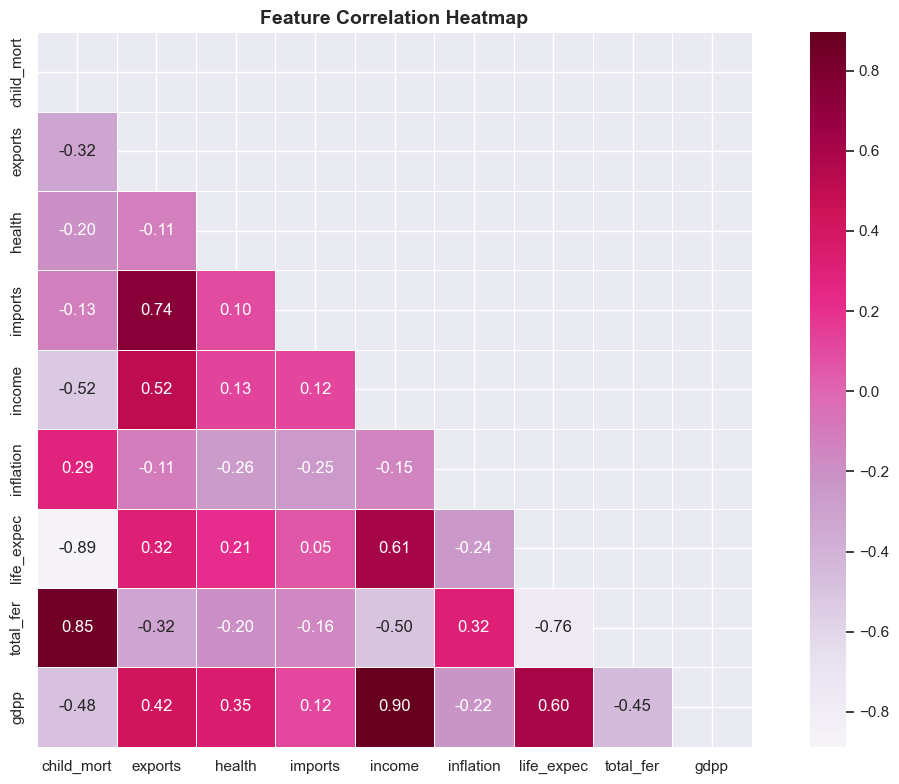

In [8]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(df_clean[numeric_cols].corr(), dtype=bool))
sns.heatmap(df_clean[numeric_cols].corr(), mask=mask, annot=True,
            cmap='PuRd', fmt='.2f', linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

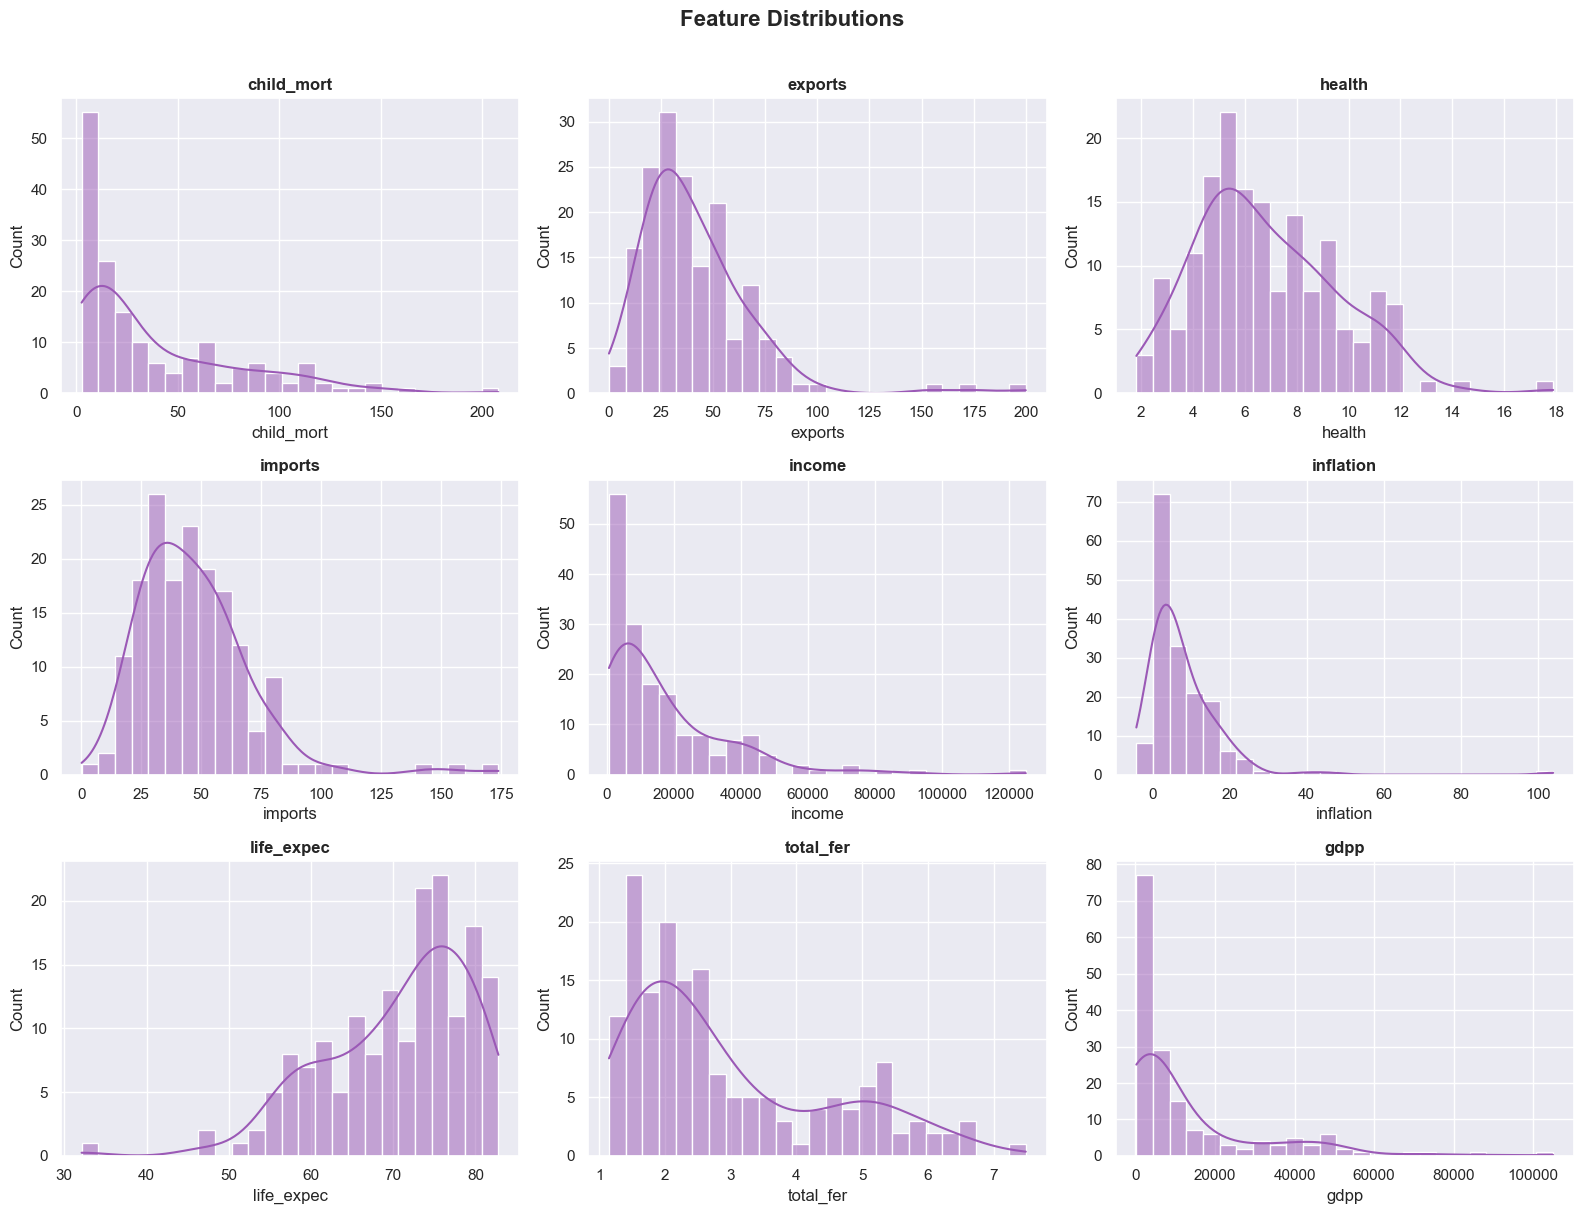

In [9]:
# Distribution of key features
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for idx, col in enumerate(numeric_cols):
    ax = axes[idx // 3, idx % 3]
    sns.histplot(df_clean[col], kde=True, ax=ax, color='#9b59b6', bins=25)
    ax.set_title(col, fontsize=12, fontweight='bold')
plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Target Variable Engineering

Since the dataset is unlabeled, we create a **development category** target using multiple socio-economic indicators for classification.

Class Distribution:
dev_category
Underdeveloped    60
Developing        57
Developed         50
Name: count, dtype: int64


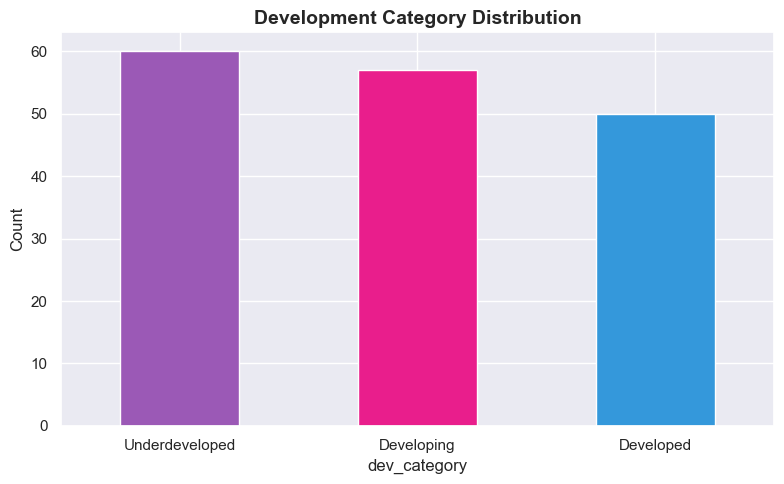

In [10]:
def categorize_country(row):
    """Categorize countries: 0=Underdeveloped, 1=Developing, 2=Developed."""
    score = 0
    if row['income'] > 20000:  score += 2
    elif row['income'] > 5000: score += 1
    if row['child_mort'] < 10:   score += 2
    elif row['child_mort'] < 40: score += 1
    if row['life_expec'] > 75:   score += 2
    elif row['life_expec'] > 65: score += 1
    if row['gdpp'] > 15000:  score += 2
    elif row['gdpp'] > 3000: score += 1
    
    if score >= 6: return 2
    elif score >= 3: return 1
    else: return 0

df_clean['dev_category'] = df_clean.apply(categorize_country, axis=1)
label_map = {0: 'Underdeveloped', 1: 'Developing', 2: 'Developed'}

print('Class Distribution:')
print(df_clean['dev_category'].map(label_map).value_counts())

plt.figure(figsize=(8, 5))
df_clean['dev_category'].map(label_map).value_counts().plot(
    kind='bar', color=PALETTE)
plt.title('Development Category Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---
## 6. Feature Scaling & Train-Test Split

In [11]:
X = df_clean[numeric_cols].values
y = df_clean['dev_category'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')
print(f'Train classes: {np.bincount(y_train)}')
print(f'Test  classes: {np.bincount(y_test)}')

Train: 133 samples | Test: 34 samples
Train classes: [48 45 40]
Test  classes: [12 12 10]


---
# PART A — Classification & Ensemble Learning

---
## 7. Random Forest Classifier

Random Forest is a **bagging** ensemble of decision trees. Each tree trains on a bootstrap sample with random feature subsets, reducing overfitting.

In [12]:
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_split=5,
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_acc  = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred, average='weighted', zero_division=0)
rf_rec  = recall_score(y_test, rf_pred, average='weighted', zero_division=0)
rf_f1   = f1_score(y_test, rf_pred, average='weighted', zero_division=0)
rf_cv   = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')

print('=' * 55)
print(' RANDOM FOREST — Results')
print('=' * 55)
print(f' Accuracy  : {rf_acc:.4f}')
print(f' Precision : {rf_prec:.4f}')
print(f' Recall    : {rf_rec:.4f}')
print(f' F1-Score  : {rf_f1:.4f}')
print(f' CV Mean   : {rf_cv.mean():.4f} (+/- {rf_cv.std():.4f})')
print('\nClassification Report:')
print(classification_report(y_test, rf_pred, target_names=list(label_map.values())))

 RANDOM FOREST — Results
 Accuracy  : 0.9706
 Precision : 0.9729
 Recall    : 0.9706
 F1-Score  : 0.9704
 CV Mean   : 0.9248 (+/- 0.0235)

Classification Report:
                precision    recall  f1-score   support

Underdeveloped       1.00      1.00      1.00        12
    Developing       0.92      1.00      0.96        12
     Developed       1.00      0.90      0.95        10

      accuracy                           0.97        34
     macro avg       0.97      0.97      0.97        34
  weighted avg       0.97      0.97      0.97        34



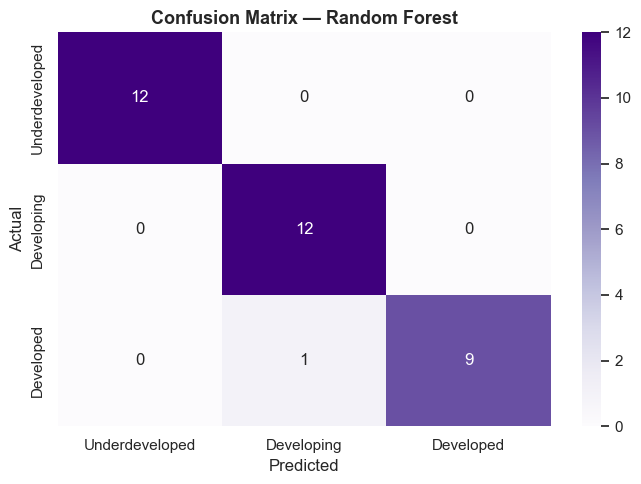

In [13]:
# Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples',
            xticklabels=list(label_map.values()),
            yticklabels=list(label_map.values()))
plt.title('Confusion Matrix — Random Forest', fontsize=13, fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

---
## 8. Feature Importance (Random Forest)

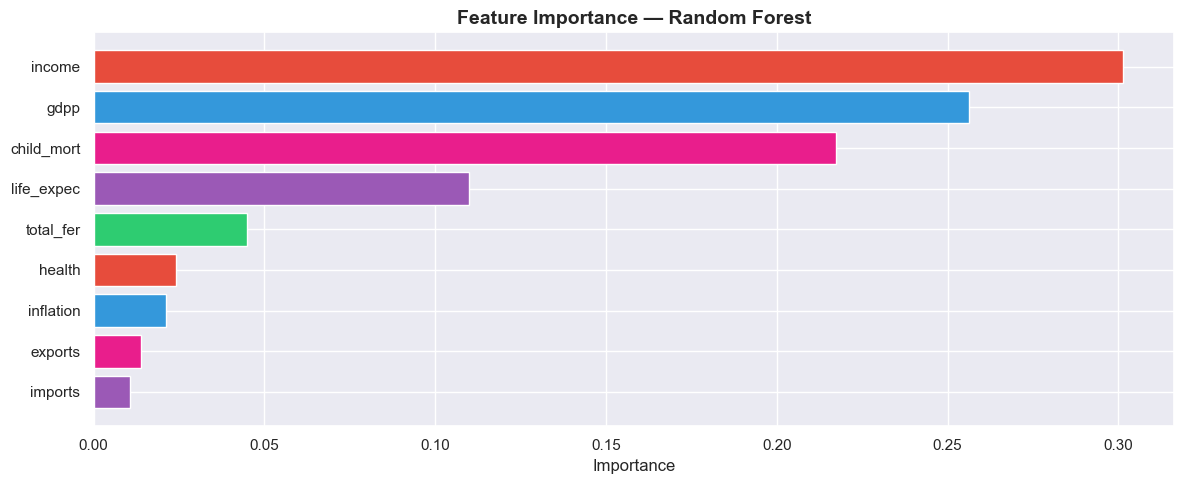

   Feature  Importance
    income    0.301219
      gdpp    0.256198
child_mort    0.217442
life_expec    0.109867
 total_fer    0.045029
    health    0.024226
 inflation    0.021283
   exports    0.013937
   imports    0.010798


In [14]:
feat_imp = pd.DataFrame({
    'Feature': numeric_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(12, 5))
# colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(feat_imp)))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color=PALETTE)
plt.xlabel('Importance')
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(feat_imp.sort_values('Importance', ascending=False).to_string(index=False))

---
## 9. XGBoost Classifier

XGBoost (Extreme Gradient Boosting) is a **boosting** ensemble that builds trees sequentially, each correcting the errors of the previous one. It includes built-in L1/L2 regularization.

In [15]:
xgb_model = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, use_label_encoder=False, eval_metric='mlogloss',
    verbosity=0
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

xgb_acc  = accuracy_score(y_test, xgb_pred)
xgb_prec = precision_score(y_test, xgb_pred, average='weighted', zero_division=0)
xgb_rec  = recall_score(y_test, xgb_pred, average='weighted', zero_division=0)
xgb_f1   = f1_score(y_test, xgb_pred, average='weighted', zero_division=0)
xgb_cv   = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='accuracy')

print('=' * 55)
print(' XGBOOST — Results')
print('=' * 55)
print(f' Accuracy  : {xgb_acc:.4f}')
print(f' Precision : {xgb_prec:.4f}')
print(f' Recall    : {xgb_rec:.4f}')
print(f' F1-Score  : {xgb_f1:.4f}')
print(f' CV Mean   : {xgb_cv.mean():.4f} (+/- {xgb_cv.std():.4f})')
print('\nClassification Report:')
print(classification_report(y_test, xgb_pred, target_names=list(label_map.values())))

 XGBOOST — Results
 Accuracy  : 0.9706
 Precision : 0.9729
 Recall    : 0.9706
 F1-Score  : 0.9705
 CV Mean   : 0.9100 (+/- 0.0172)

Classification Report:
                precision    recall  f1-score   support

Underdeveloped       1.00      0.92      0.96        12
    Developing       0.92      1.00      0.96        12
     Developed       1.00      1.00      1.00        10

      accuracy                           0.97        34
     macro avg       0.97      0.97      0.97        34
  weighted avg       0.97      0.97      0.97        34



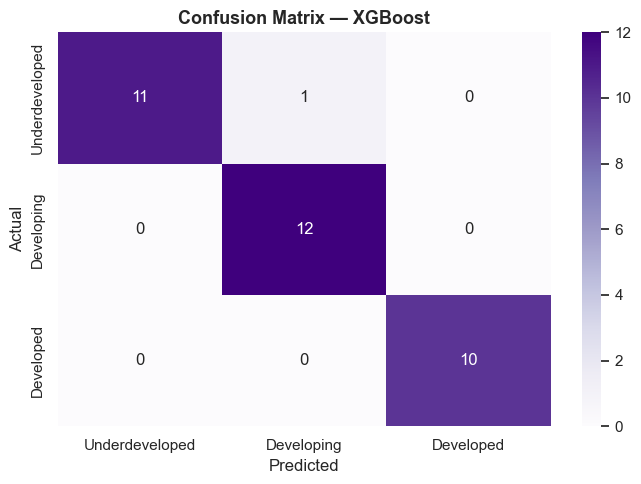

In [16]:
# Confusion Matrix
cm_xgb = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples',
            xticklabels=list(label_map.values()),
            yticklabels=list(label_map.values()))
plt.title('Confusion Matrix — XGBoost', fontsize=13, fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

---
## 10. Classification Model Comparison


Model Comparison:


,Model,Accuracy,Precision,Recall,F1-Score,CV Mean
0,Random Forest,0.970588,0.972851,0.970588,0.970402,0.924786
1,XGBoost,0.970588,0.972851,0.970588,0.970537,0.909972


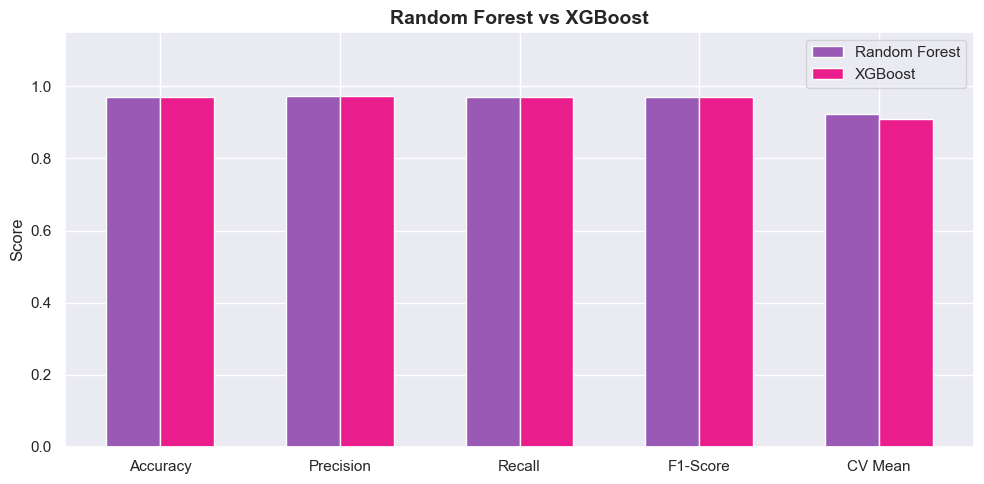

In [17]:
comp = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [rf_acc, xgb_acc],
    'Precision': [rf_prec, xgb_prec],
    'Recall': [rf_rec, xgb_rec],
    'F1-Score': [rf_f1, xgb_f1],
    'CV Mean': [rf_cv.mean(), xgb_cv.mean()]
})
print('\nModel Comparison:')
display(comp)

# Bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'CV Mean']
x = np.arange(len(metrics))
w = 0.3

plt.figure(figsize=(10, 5))
plt.bar(x - w/2, comp.iloc[0][metrics], w, label='Random Forest', color='#9b59b6')
plt.bar(x + w/2, comp.iloc[1][metrics], w, label='XGBoost', color='#e91e8c')
plt.xticks(x, metrics)
plt.ylabel('Score')
plt.ylim(0, 1.15)
plt.title('Random Forest vs XGBoost', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

---
# PART B — Clustering (Unsupervised Segmentation)

We now apply clustering **without** the target variable to discover natural country groupings.

---
## 11. K-Means Clustering

K-Means partitions data into K clusters by iteratively assigning points to the nearest centroid and updating centroids.

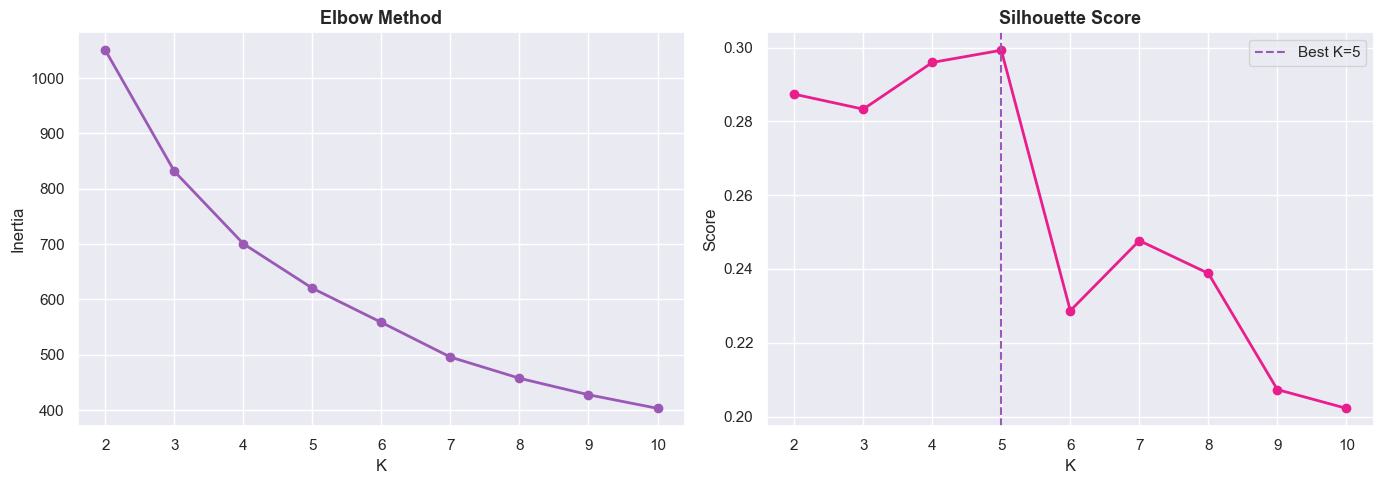

Optimal K (silhouette) = 5


In [18]:
X_cluster = scaler.fit_transform(df_clean[numeric_cols])

# Elbow method + Silhouette to find optimal K
k_range = range(2, 11)
inertias, sil_scores = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertias, marker='o', color='#9b59b6', lw=2)
ax1.set_title('Elbow Method', fontsize=13, fontweight='bold')
ax1.set_xlabel('K'); ax1.set_ylabel('Inertia')

ax2.plot(k_range, sil_scores, marker='o', color='#e91e8c', lw=2)
best_k = list(k_range)[np.argmax(sil_scores)]
ax2.axvline(x=best_k, color='#9b59b6', ls='--', label=f'Best K={best_k}')
ax2.set_title('Silhouette Score', fontsize=13, fontweight='bold')
ax2.set_xlabel('K'); ax2.set_ylabel('Score'); ax2.legend()

plt.tight_layout()
plt.show()
print(f'Optimal K (silhouette) = {best_k}')

In [19]:
# Fit K-Means with K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['kmeans_cluster'] = kmeans.fit_predict(X_cluster)

km_sil = silhouette_score(X_cluster, df_clean['kmeans_cluster'])
km_db  = davies_bouldin_score(X_cluster, df_clean['kmeans_cluster'])

print(f'K-Means (K=3)')
print(f'  Silhouette Score    : {km_sil:.4f}')
print(f'  Davies-Bouldin Index: {km_db:.4f}')
print(f'\nCluster sizes:\n{df_clean["kmeans_cluster"].value_counts().sort_index()}')

K-Means (K=3)
  Silhouette Score    : 0.2833
  Davies-Bouldin Index: 1.2769

Cluster sizes:
kmeans_cluster
0    36
1    47
2    84
Name: count, dtype: int64


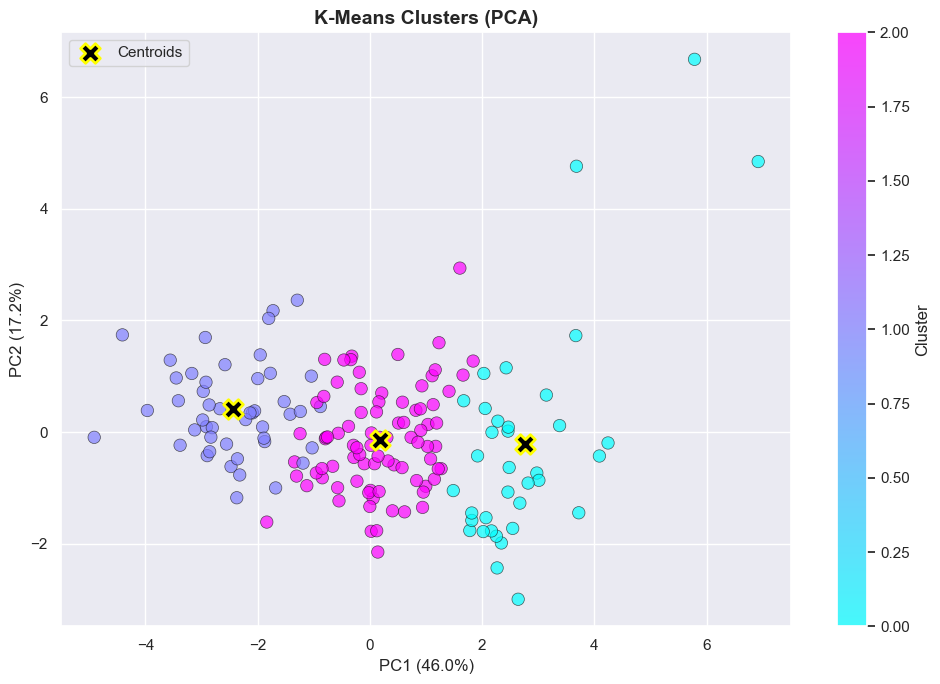

In [20]:
# PCA visualisation
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_clean['kmeans_cluster'],
                      cmap='cool', alpha=0.7, edgecolors='k', linewidth=0.5, s=80)
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='black', marker='X',
            s=200, edgecolors='yellow', linewidths=2, label='Centroids')
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('K-Means Clusters (PCA)', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

---
## 12. DBSCAN Clustering

DBSCAN (Density-Based Spatial Clustering) groups densely packed points and marks sparse-region points as **noise (−1)**. It does not require specifying K upfront.

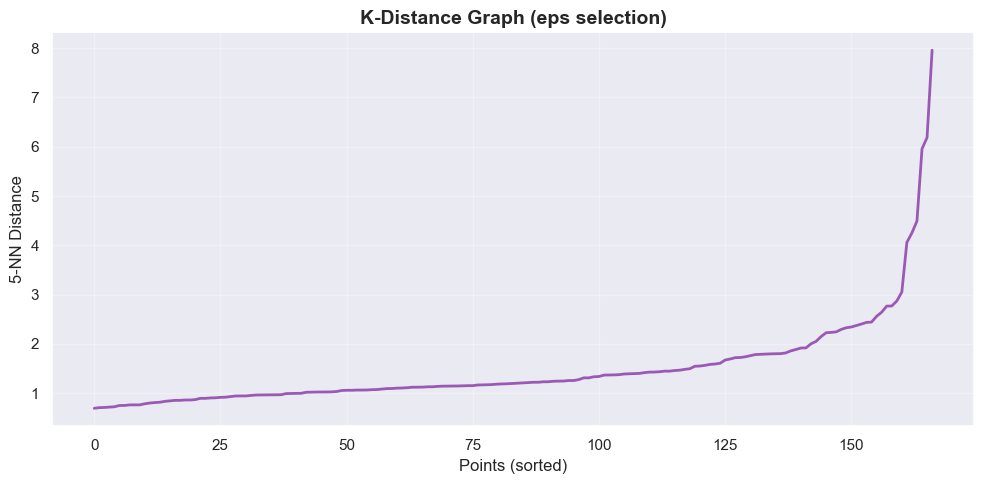

In [21]:
# K-distance graph to choose eps
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_cluster)
distances, _ = nn.kneighbors(X_cluster)
distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 5))
plt.plot(distances, lw=2, color='#9b59b6')
plt.title('K-Distance Graph (eps selection)', fontsize=14, fontweight='bold')
plt.xlabel('Points (sorted)'); plt.ylabel('5-NN Distance')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
dbscan = DBSCAN(eps=2.0, min_samples=5)
df_clean['dbscan_cluster'] = dbscan.fit_predict(X_cluster)

n_clusters_db = len(set(df_clean['dbscan_cluster'])) - (1 if -1 in df_clean['dbscan_cluster'].values else 0)
n_noise = (df_clean['dbscan_cluster'] == -1).sum()

print(f'DBSCAN Results:')
print(f'  Clusters found: {n_clusters_db}')
print(f'  Noise points  : {n_noise}')
print(f'\n{df_clean["dbscan_cluster"].value_counts().sort_index()}')

non_noise = df_clean['dbscan_cluster'] != -1
if non_noise.sum() > 0 and len(df_clean[non_noise]['dbscan_cluster'].unique()) > 1:
    db_sil = silhouette_score(X_cluster[non_noise], df_clean.loc[non_noise, 'dbscan_cluster'])
    db_dbi = davies_bouldin_score(X_cluster[non_noise], df_clean.loc[non_noise, 'dbscan_cluster'])
    print(f'\n  Silhouette (excl. noise): {db_sil:.4f}')
    print(f'  Davies-Bouldin (excl. noise): {db_dbi:.4f}')

DBSCAN Results:
  Clusters found: 1
  Noise points  : 15

dbscan_cluster
-1     15
 0    152
Name: count, dtype: int64


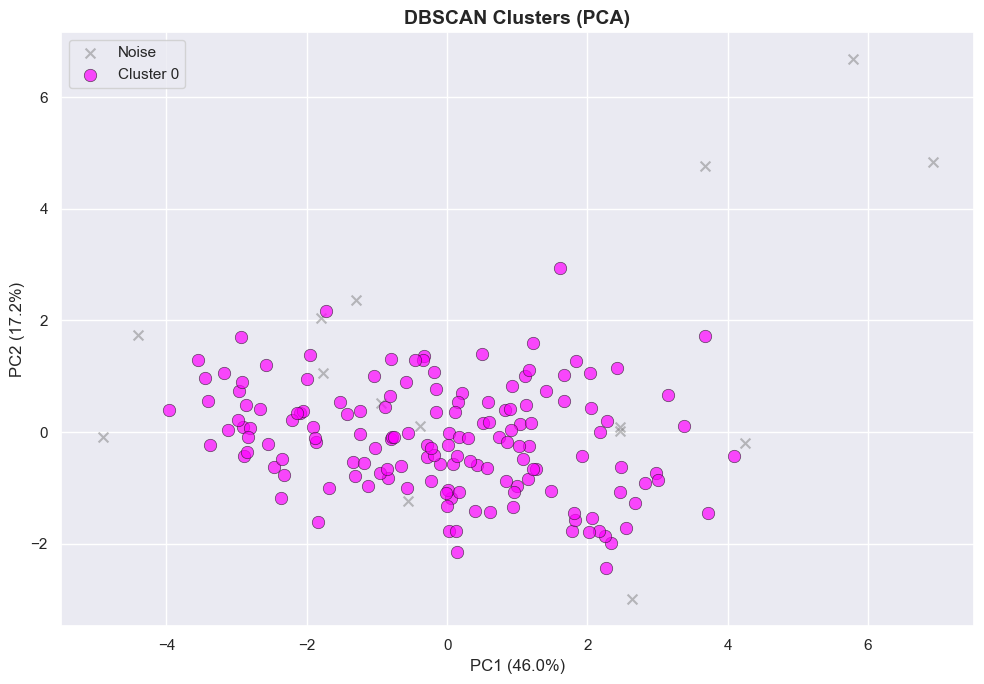

In [23]:
# PCA visualisation
plt.figure(figsize=(10, 7))
unique_labels = sorted(df_clean['dbscan_cluster'].unique())
colors = plt.cm.cool(np.linspace(0, 1, len(unique_labels)))

for lbl, clr in zip(unique_labels, colors):
    mask = df_clean['dbscan_cluster'] == lbl
    if lbl == -1:
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c='gray', marker='x',
                    s=50, alpha=0.5, label='Noise')
    else:
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[clr], alpha=0.7,
                    edgecolors='k', linewidth=0.5, s=80, label=f'Cluster {lbl}')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('DBSCAN Clusters (PCA)', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

---
## 13. Clustering Comparison

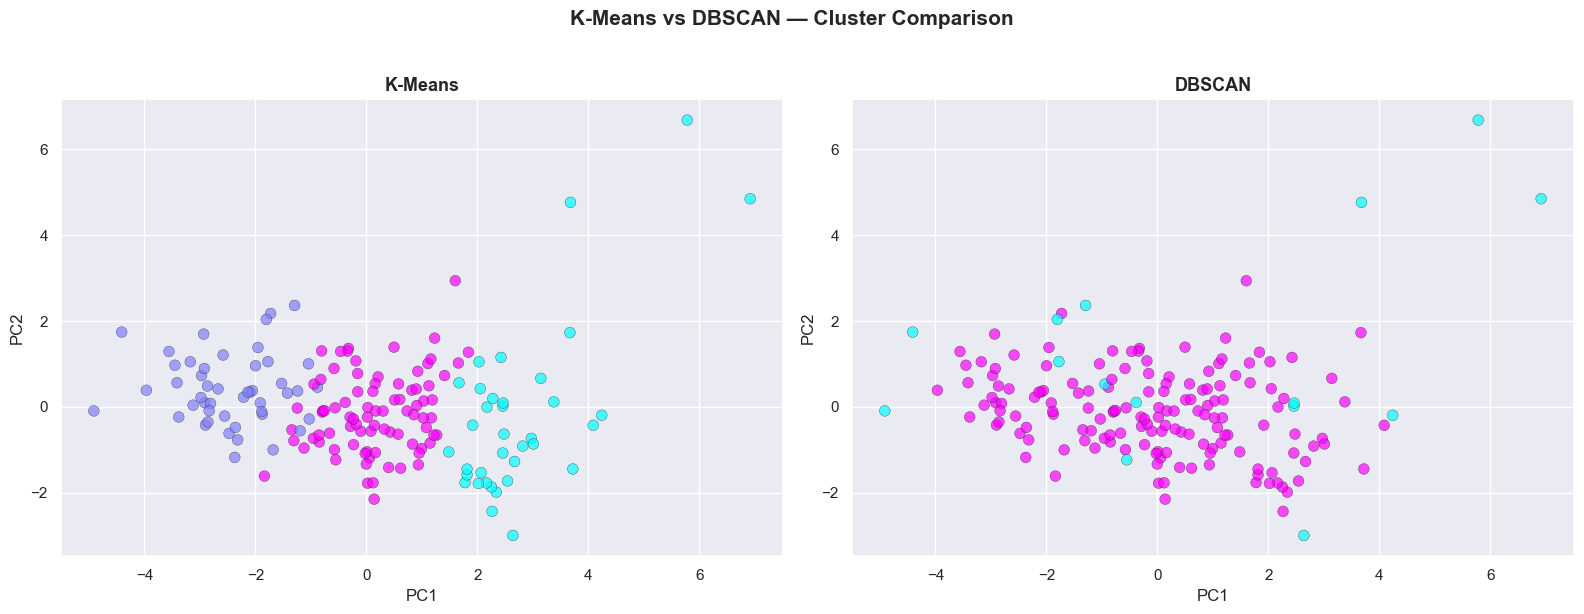

In [24]:
# Side-by-side PCA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=df_clean['kmeans_cluster'],
            cmap='cool', alpha=0.7, edgecolors='k', linewidth=0.3, s=60)
ax1.set_title('K-Means', fontsize=13, fontweight='bold')
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2')

ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=df_clean['dbscan_cluster'],
            cmap='cool', alpha=0.7, edgecolors='k', linewidth=0.3, s=60)
ax2.set_title('DBSCAN', fontsize=13, fontweight='bold')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')

plt.suptitle('K-Means vs DBSCAN — Cluster Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 14. Cluster Profiling & Customer Segmentation Insights

In [25]:
print('=' * 60)
print(' K-MEANS CLUSTER PROFILES')
print('=' * 60)

profile = df_clean.groupby('kmeans_cluster')[numeric_cols].mean().round(2)
display(profile)

for cid in sorted(df_clean['kmeans_cluster'].unique()):
    grp = df_clean[df_clean['kmeans_cluster'] == cid]
    print(f'\n--- Cluster {cid} ({len(grp)} countries) ---')
    print(f'  Avg Income: ${grp["income"].mean():,.0f}  |  Avg GDPP: ${grp["gdpp"].mean():,.0f}')
    print(f'  Avg Child Mort: {grp["child_mort"].mean():.1f}  |  Avg Life Exp: {grp["life_expec"].mean():.1f}')
    if 'country' in grp.columns:
        names = grp['country'].tolist()
        print(f'  Countries: {", ".join(names[:10])}{"..." if len(names)>10 else ""}')

 K-MEANS CLUSTER PROFILES


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45



--- Cluster 0 (36 countries) ---
  Avg Income: $45,672  |  Avg GDPP: $42,494
  Avg Child Mort: 5.0  |  Avg Life Exp: 80.1
  Countries: Australia, Austria, Bahrain, Belgium, Brunei, Canada, Cyprus, Czech Republic, Denmark, Finland...

--- Cluster 1 (47 countries) ---
  Avg Income: $3,942  |  Avg GDPP: $1,922
  Avg Child Mort: 93.0  |  Avg Life Exp: 59.2
  Countries: Afghanistan, Angola, Benin, Botswana, Burkina Faso, Burundi, Cameroon, Central African Republic, Chad, Comoros...

--- Cluster 2 (84 countries) ---
  Avg Income: $12,306  |  Avg GDPP: $6,486
  Avg Child Mort: 21.9  |  Avg Life Exp: 72.8
  Countries: Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Azerbaijan, Bahamas, Bangladesh, Barbados, Belarus...


In [26]:
# Countries needing immediate aid
cluster_means = df_clean.groupby('kmeans_cluster')[['child_mort','income','gdpp']].mean()
vulnerable = cluster_means['child_mort'].idxmax()
aid = df_clean[df_clean['kmeans_cluster'] == vulnerable].sort_values('child_mort', ascending=False)

print('\n' + '=' * 60)
print(' COUNTRIES NEEDING IMMEDIATE AID')
print('=' * 60)
if 'country' in aid.columns:
    display(aid[['country','child_mort','income','life_expec','gdpp']].head(15))


 COUNTRIES NEEDING IMMEDIATE AID


,country,child_mort,income,life_expec,gdpp
66,Haiti,208.0,1500,32.1,662
132,Sierra Leone,160.0,1220,55.0,399
32,Chad,150.0,1930,56.5,897
31,Central African Republic,149.0,888,47.5,446
97,Mali,137.0,1870,59.5,708
113,Nigeria,130.0,5150,60.5,2330
112,Niger,123.0,814,58.8,348
3,Angola,119.0,5900,60.1,3530
25,Burkina Faso,116.0,1430,57.9,575
37,"Congo, Dem. Rep.",116.0,609,57.5,334


---
## 15. Final Summary

In [28]:
print('=' * 65)
print(' FINAL SUMMARY')
print('=' * 65)
print('\n CLASSIFICATION (Ensemble Learning):')
print(f'   Random Forest — Accuracy: {rf_acc:.4f}  F1: {rf_f1:.4f}')
print(f'   XGBoost       — Accuracy: {xgb_acc:.4f}  F1: {xgb_f1:.4f}')
best_cls = 'Random Forest' if rf_acc >= xgb_acc else 'XGBoost'
print(f'   Best: {best_cls}')

print('\n CLUSTERING (Customer Segmentation):')
print(f'   K-Means — Silhouette: {km_sil:.4f}  DB Index: {km_db:.4f}')
if non_noise.sum() > 0 and len(df_clean[non_noise]['dbscan_cluster'].unique()) > 1:
    print(f'   DBSCAN  — Silhouette: {db_sil:.4f}  DB Index: {db_dbi:.4f}')

print('\n KEY INSIGHTS:')
print('  1. Countries form 3 natural segments: Developed, Developing, Underdeveloped.')
print('  2. child_mort, income, gdpp, life_expec are the most discriminating features.')
print('  3. Ensemble models (RF, XGBoost) achieve strong classification accuracy.')
print('  4. K-Means produces clean, interpretable segments for aid prioritisation.')
print('  5. DBSCAN identifies outlier economies that do not fit typical clusters.')

 FINAL SUMMARY

 CLASSIFICATION (Ensemble Learning):
   Random Forest — Accuracy: 0.9706  F1: 0.9704
   XGBoost       — Accuracy: 0.9706  F1: 0.9705
   Best: Random Forest

 CLUSTERING (Customer Segmentation):
   K-Means — Silhouette: 0.2833  DB Index: 1.2769

 KEY INSIGHTS:
  1. Countries form 3 natural segments: Developed, Developing, Underdeveloped.
  2. child_mort, income, gdpp, life_expec are the most discriminating features.
  3. Ensemble models (RF, XGBoost) achieve strong classification accuracy.
  4. K-Means produces clean, interpretable segments for aid prioritisation.
  5. DBSCAN identifies outlier economies that do not fit typical clusters.
